make harmonic oscillator -
in tramsmon they become anharmonic to fabricate seperate energy level states -
here it remains a QHO -
since the qubit is in phase space lattice rather than energy levels

$a|n> sqrt n |n-1>$ qft, a.dag is creation
q = (a + a.dag()) / np.sqrt(2) # p and q qft vectors things
p =  np.imag (a.dag() - a) / np.sqrt(2) # the p axis
Hqho = -np.cos(2*np.sqrt(np.pi)*q) -np.cos(2*np.sqrt(np.pi)*p) 

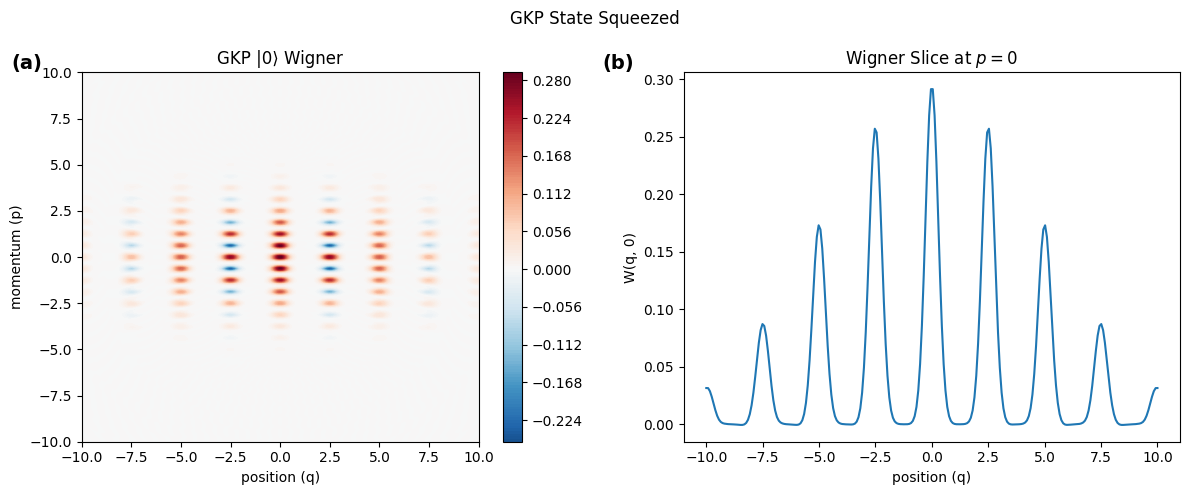

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
N = 120 #foch cutoff - foch space qft - the n inside the ket
#need large cutoff
delta = 0.4 #peak width
epsilon = 0.25
n = 5 #number of peaks

#vaccum
vac = basis(N, 0)

#squeezing - narrow gauss - stat phys
r = -np.log(delta) 
S = squeeze(N, r)
peak_state = S * vac

#builds gkp logical 0
# = sum k | q = 2k sqrt pi>
epsilon = 0.2
gkp0 = 0
for k in range(-n, n + 1):
    weight = np.exp(-2 * np.pi * epsilon**2 * k**2)
    D = displace(N, 2 * k * np.sqrt(np.pi))
    gkp0 += weight * D * peak_state

gkp0 = gkp0.unit() #normalise

#logical 1 gkp
# = sum k | q = 2k+1 sqrt pi>
gkp1 = displace(N, np.sqrt(np.pi)) * gkp0 #shifts by sqrt pi
gkp1 = gkp1.unit()

# phase space 
grid = 250
xvec = np.linspace(-10, 10, grid)
W = wigner(gkp0, xvec, xvec, method='clenshaw')

#plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GKP State Squeezed')

# 3d wigner f
lim = np.max(np.abs(W))
cont = ax1.contourf(xvec, xvec, W, 150, cmap='RdBu_r', vmin=-lim, vmax=lim)
ax1.text(-0.1, 1.05, "(a)", transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
ax2.text(-0.1, 1.05, "(b)", transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# colourbar
fig.colorbar(cont, ax=ax1) 
ax1.set_title("GKP |0⟩ Wigner")
ax1.set_xlabel("position (q)")
ax1.set_ylabel("momentum (p)")

#2d slice p=0
ax2.plot(xvec, W[grid // 2, :])
ax2.set_title("Wigner Slice at $p = 0$")
ax2.set_xlabel("position (q)")
ax2.set_ylabel("W(q, 0)")

#my_rgb = (219/255, 229/255, 249/255) # my pp light blue background
#fig.set_facecolor(my_rgb) 

#keep plots white when change background colour
ax1.set_facecolor('white')
ax2.set_facecolor('white')

plt.tight_layout() 
plt.show()


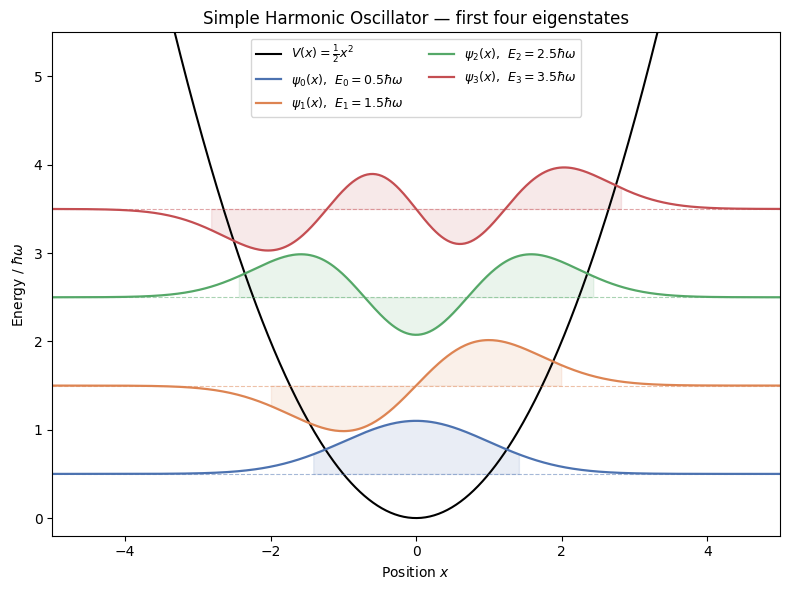

In [2]:
x = np.linspace(-5, 5, 500)
V = 0.5 * x**2                          # potential well

levels_to_plot = [0, 1, 2, 3]           # which eigenstates to show
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig_sho, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, V, 'k-', lw=1.5, label='$V(x) = \\frac{1}{2}x^2$')

for idx, n_level in enumerate(levels_to_plot):
    E_n = n_level + 0.5                  # energy eigenvalue (ħω = 1)
    
    # Hermite polynomial via qutip: project position-basis wavefunction
    state = basis(N, n_level)
    psi = state.full().flatten()
    
    # Build wavefunction on x-grid using harmonic oscillator basis functions
    # ψ_n(x) = (2^n n! √π)^{-1/2} H_n(x) exp(-x²/2)
    from scipy.special import hermite, factorial
    H_n = hermite(n_level)
    norm = (2**n_level * factorial(n_level) * np.sqrt(np.pi))**(-0.5)
    psi_x = norm * H_n(x) * np.exp(-x**2 / 2)
    
    scale = 0.8                          # visual amplitude scale
    ax.axhline(E_n, color=colors[idx], lw=0.8, ls='--', alpha=0.5)
    ax.plot(x, scale * psi_x + E_n, color=colors[idx], lw=1.6,
            label=f'$\\psi_{n_level}(x)$,  $E_{n_level} = {E_n}\\hbar\\omega$')
    ax.fill_between(x, E_n, scale * psi_x + E_n,
                    where=(np.abs(x) < np.sqrt(2 * E_n + 1)),   # classically allowed
                    color=colors[idx], alpha=0.12)

ax.set_xlim(-5, 5)
ax.set_ylim(-0.2, 5.5)
ax.set_xlabel('Position $x$')
ax.set_ylabel('Energy / $\\hbar\\omega$')
ax.set_title('Simple Harmonic Oscillator — first four eigenstates')
ax.legend(loc='upper center', fontsize=9, ncol=2)
ax.set_facecolor('white')
plt.tight_layout()

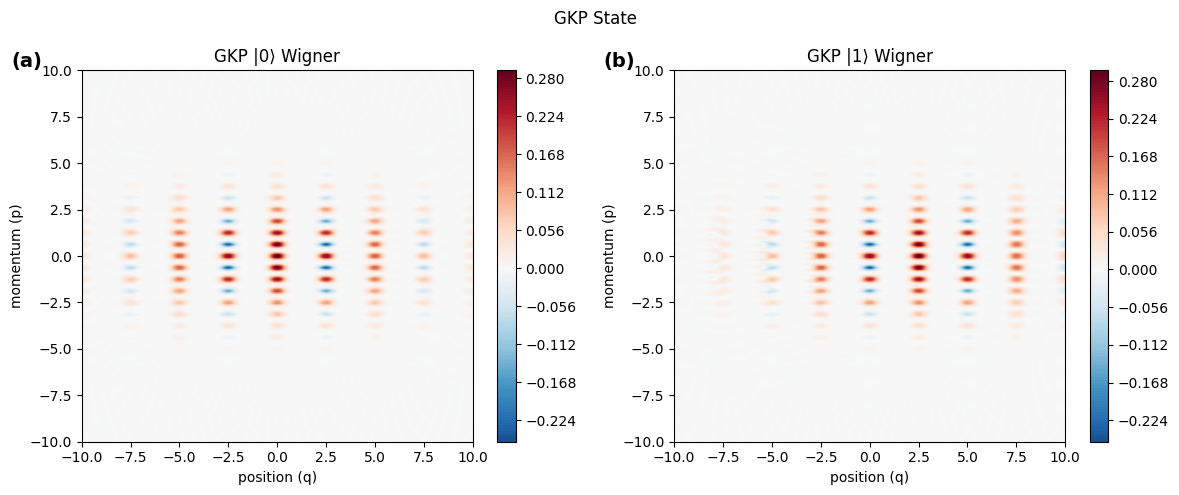

In [2]:
#make again for 0 state
grid = 250
xvec = np.linspace(-10, 10, grid)
W0 = wigner(gkp0, xvec, xvec, method='clenshaw')

#make again for 1 state
grid = 250
xvec = np.linspace(-10, 10, grid)
W1 = wigner(gkp1, xvec, xvec, method='clenshaw')

#plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GKP State')

# 3d wigner f
lim0 = np.max(np.abs(W0))
cont0 = ax1.contourf(xvec, xvec, W0, 150, cmap='RdBu_r', vmin=-lim, vmax=lim)
ax1.text(-0.1, 1.05, "(a)", transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
# colourbar
fig.colorbar(cont0, ax=ax1) 
ax1.set_title("GKP |0⟩ Wigner")
ax1.set_xlabel("position (q)")
ax1.set_ylabel("momentum (p)")

# 3d for 1
lim1 = np.max(np.abs(W1))
cont1 = ax2.contourf(xvec, xvec, W1, 150, cmap='RdBu_r', vmin=-lim, vmax=lim)
ax2.text(-0.1, 1.05, "(b)", transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
# for 1
fig.colorbar(cont1, ax=ax2)
ax2.set_title("GKP |1⟩ Wigner")
ax2.set_xlabel("position (q)")
ax2.set_ylabel("momentum (p)")

#my_rgb = (219/255, 229/255, 249/255) # my pp light blue background
#fig.set_facecolor(my_rgb) 

#keep plots white when change background colour
ax1.set_facecolor('white')
ax2.set_facecolor('white')

plt.tight_layout() 
plt.show()


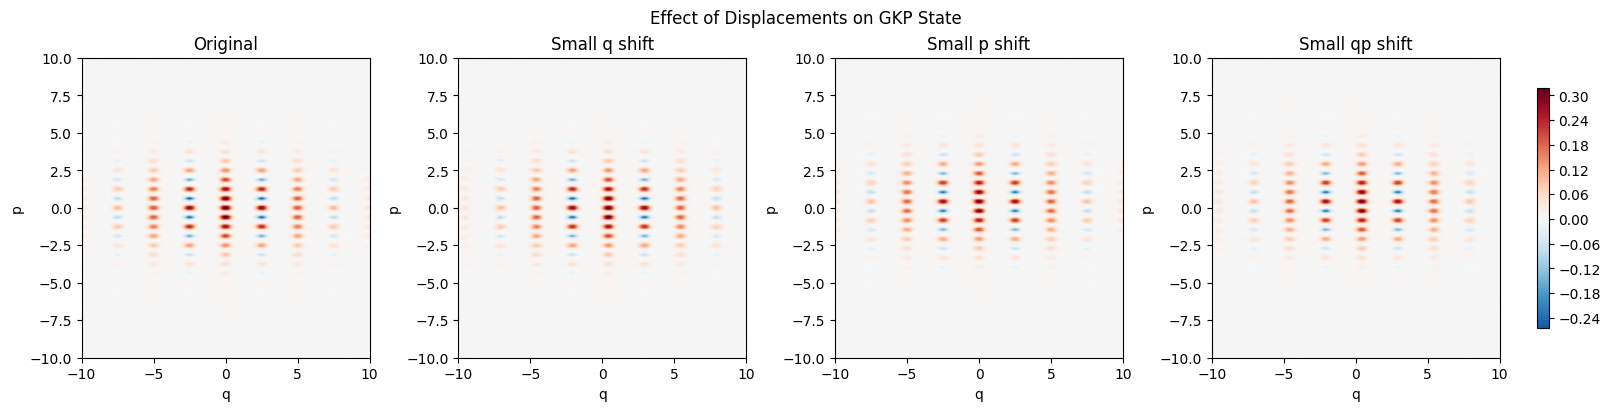

<Figure size 640x480 with 0 Axes>

In [18]:
sqrt_pi = np.sqrt(np.pi)

#small displacements 
small_q = displace(N, 0.3)*gkp0
small_p = displace(N, 0.3j)*gkp0
small_qp = displace(N, 0.3+0.3j)*gkp0

#large displacemts that manifest as pauli errors 
X = displace(N, sqrt_pi)*gkp0 #takes 0 to 1
Z = displace(N, 1j*sqrt_pi)*gkp0 #phase flip will not change phase of 0 just move lattice site
Y = displace(N, sqrt_pi*(1+1j))*gkp0 # Y = iXZ does both

#normalise everything
small_q = small_q.unit()
small_p = small_p.unit()
small_qp = small_qp.unit()
X = X.unit()
Y = Y.unit()
Z = Z.unit()

#states list
states1 = [
    ("Original", gkp0),
    ("Small q shift", small_q),
    ("Small p shift", small_p),
    ("Small qp shift", small_qp),
]

#plot function 
def plot_wigner(ax, state, xvec, title):
    W = wigner(state, xvec, xvec, method='clenshaw')
    lim = np.max(np.abs(W))
    cont = ax.contourf(xvec, xvec, W, 100, cmap='RdBu_r',
                       vmin=-lim, vmax=lim)
    ax.set_title(title)
    ax.set_xlabel("q")
    ax.set_ylabel("p")
    ax.set_facecolor('white')
    return cont

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
axes = axes.flatten()

for i, (label, state) in enumerate(states1):
    cont = plot_wigner(axes[i], state, xvec, label)

cbar = fig.colorbar(cont, ax=axes, location='right', shrink=0.8, pad=0.02)
plt.suptitle("Effect of Displacements on GKP State")
plt.show()

plt.tight_layout(pad=2.0)
plt.suptitle("Effect of Displacements on GKP State") 
plt.show()

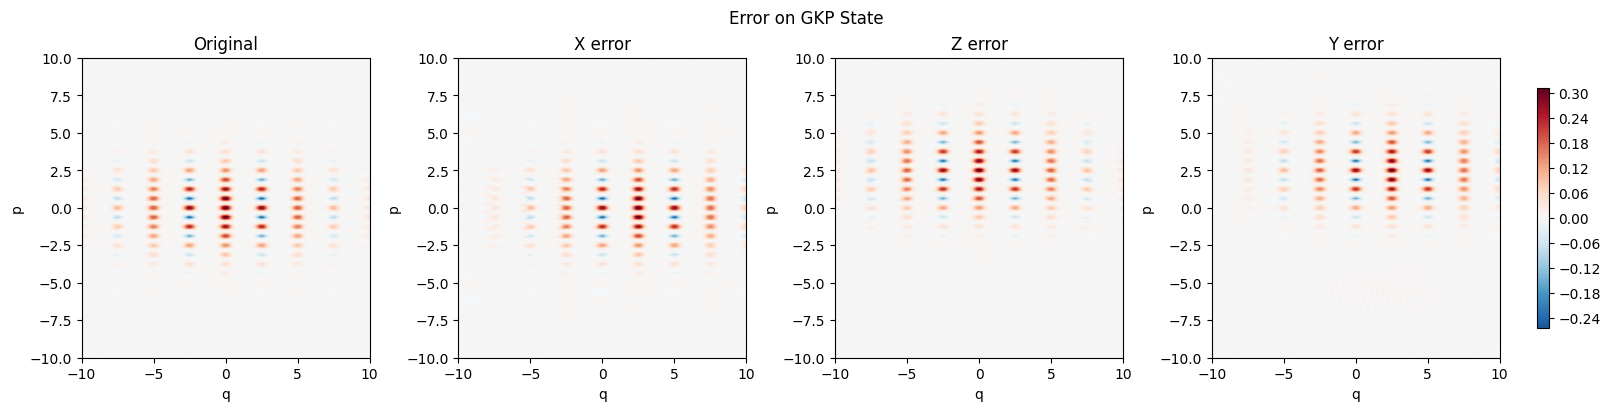

<Figure size 640x480 with 0 Axes>

In [19]:
states2 = [
    ("Original", gkp0),
    ("X error", X),
    ("Z error", Z),
    ("Y error", Y)
    ]

#plot function 
def plot_wigner(ax, state, xvec, title):
    W = wigner(state, xvec, xvec, method='clenshaw')
    lim = np.max(np.abs(W))
    cont = ax.contourf(xvec, xvec, W, 100, cmap='RdBu_r',
                       vmin=-lim, vmax=lim)
    ax.set_title(title)
    ax.set_xlabel("q")
    ax.set_ylabel("p")
    ax.set_facecolor('white')
    return cont

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
axes = axes.flatten()

for i, (label, state) in enumerate(states2):
    cont = plot_wigner(axes[i], state, xvec, label)

cbar = fig.colorbar(cont, ax=axes, location='right', shrink=0.8, pad=0.02)
plt.suptitle("Error on GKP State")
plt.show()

plt.tight_layout(pad=2.0)
plt.suptitle("Effect of Displacements on GKP State") 
plt.show()